In [8]:
# use the venv thats at STAT_443_FINAL_PROJECT
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
# Load Dataset 
data = pd.read_csv("/Users/sorenbasnet/Documents/Github/STAT_443_FINAL_PROJECT/data/prediction_death_5_years/data_patient_file_cna_rai.txt", sep=r'\s+',index_col=0)
data.head()

,ONCOTREE_CODE,DISEASE_TYPE,NORMAL_MEAN_COVERAGE,TUMOR_MEAN_COVERAGE,TUMOR_SAMPLE_PURITY,TUMOR_SAMPLE_PLOIDY,CANCER_TYPE,CANCER_TYPE_DETAILED,SOMATIC_STATUS,CLL_EPITYPE,TUMOR_MOLECULAR_SUBTYPE,SEQUENCING_PLATFORM,RNA_SEQUENCING,RRBS,ARRAY450K,M.CLL_WES,U.CLL_WES,EC_DISCOVERY,EC_EXTENSION,IGLV3_21_R110,U1_STATUS,TMB_NONSYNONYMOUS,AGE,AGE_SAMPLING,SEX,OS_STATUS,OS_MONTHS,DEATH_DAYS,COHORT,IGHV_MUTATION_STATUS,IGHV_IDENTITY_PERCENTAGE,TREATMENT_STATUS,PRIOR_TREATMENT_CATEGORY,TREATMENT_AFTER_SAMPLING,EXPRESSION_CLUSTER,FFS_STATUS,FFS_MONTHS,11q_status,17p_status,17q_status,18p_status,19q_status,20p_status,2p_status,4p_status,6q_status,8p_status,8q_status,tri12_status,TREATMENT_STATUS_AT_SAMPLING,RAI_AT_SAMPLING,FIRST_TREATMENT_AFTER_SAMPLING,surv_5yrs,death_5yr
SAMPLE_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CRC_0001,CLLSLL,CLL,63.0,79.7,0.92,2.00,Mature__B_Cell__Neoplasms,Chronic__Lymphocytic__Leukemia_Small__Lymphocy...,Matched,n_CLL,U_CLL,WES,Yes,Yes,No,No,Yes,Yes,No,No,WT,0.866667,44.0,46.0,Female,DECEASED,147.19,4477.0,UCSD,unmutated,100.00,Pre_treatment,Untreated,Chemo__+__Ab,EC_u1,1:Failure,43.17,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Gain,Unchanged,Untreated,0.0,Chemo__+__Ab,60.00,0.0
CRC_0002,CLLSLL,CLL,70.1,135.5,0.94,2.03,Mature__B_Cell__Neoplasms,Chronic__Lymphocytic__Leukemia_Small__Lymphocy...,Matched,n_CLL,U_CLL,WES,Yes,Yes,No,No,Yes,Yes,No,No,WT,0.766667,55.0,56.0,Male,DECEASED,154.49,4699.0,UCSD,unmutated,100.00,Pre_treatment,Untreated,Chemo__+__Ab,EC_u1,1:Failure,66.64,Unchanged,Unchanged,Unchanged,Loss,Unchanged,Unchanged,Gain,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Untreated,0.0,Chemo__+__Ab,60.00,0.0
CRC_0003,CLLSLL,CLL,77.2,141.1,0.83,2.05,Mature__B_Cell__Neoplasms,Chronic__Lymphocytic__Leukemia_Small__Lymphocy...,Matched,n_CLL,U_CLL,WES,Yes,Yes,No,No,Yes,Yes,No,No,WT,0.233333,63.0,63.0,Female,DECEASED,51.25,1559.0,UCSD,unmutated,100.00,Pre_treatment,Untreated,Chemo__+__Ab,EC_u2,1:Failure,27.75,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Gain,Untreated,0.0,Chemo__+__Ab,51.25,1.0
CRC_0004,CLLSLL,CLL,60.2,146.0,0.92,2.00,Mature__B_Cell__Neoplasms,Chronic__Lymphocytic__Leukemia_Small__Lymphocy...,Matched,m_CLL,M_CLL,WES,Yes,Yes,No,Yes,No,Yes,No,No,WT,1.000000,51.0,51.0,Male,LIVING,183.55,0.0,UCSD,mutated,92.28,Pre_treatment,Untreated,Chemo__+__Ab,EC_m4,1:Failure,92.48,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Untreated,0.0,Chemo__+__Ab,60.00,0.0
CRC_0005,CLLSLL,CLL,106.5,82.1,0.87,2.05,Mature__B_Cell__Neoplasms,Chronic__Lymphocytic__Leukemia_Small__Lymphocy...,Matched,n_CLL,U_CLL,WES,Yes,Yes,No,No,Yes,Yes,No,No,WT,0.766667,36.0,37.0,Male,LIVING,164.35,0.0,UCSD,unmutated,100.00,Pre_treatment,Untreated,Chemo__+__Ab,EC_u2,1:Failure,59.57,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Unchanged,Gain,Untreated,0.0,Chemo__+__Ab,60.00,0.0


In [4]:
data.columns

Index(['ONCOTREE_CODE', 'DISEASE_TYPE', 'NORMAL_MEAN_COVERAGE',
       'TUMOR_MEAN_COVERAGE', 'TUMOR_SAMPLE_PURITY', 'TUMOR_SAMPLE_PLOIDY',
       'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'SOMATIC_STATUS', 'CLL_EPITYPE',
       'TUMOR_MOLECULAR_SUBTYPE', 'SEQUENCING_PLATFORM', 'RNA_SEQUENCING',
       'RRBS', 'ARRAY450K', 'M.CLL_WES', 'U.CLL_WES', 'EC_DISCOVERY',
       'EC_EXTENSION', 'IGLV3_21_R110', 'U1_STATUS', 'TMB_NONSYNONYMOUS',
       'AGE', 'AGE_SAMPLING', 'SEX', 'OS_STATUS', 'OS_MONTHS', 'DEATH_DAYS',
       'COHORT', 'IGHV_MUTATION_STATUS', 'IGHV_IDENTITY_PERCENTAGE',
       'TREATMENT_STATUS', 'PRIOR_TREATMENT_CATEGORY',
       'TREATMENT_AFTER_SAMPLING', 'EXPRESSION_CLUSTER', 'FFS_STATUS',
       'FFS_MONTHS', '11q_status', '17p_status', '17q_status', '18p_status',
       '19q_status', '20p_status', '2p_status', '4p_status', '6q_status',
       '8p_status', '8q_status', 'tri12_status',
       'TREATMENT_STATUS_AT_SAMPLING', 'RAI_AT_SAMPLING',
       'FIRST_TREATMENT_AFTER_SA

In [5]:
data = data.dropna(subset=["death_5yr"])

In [6]:
X = data.drop(columns=['ONCOTREE_CODE', 'DISEASE_TYPE', 'NORMAL_MEAN_COVERAGE',
       'TUMOR_MEAN_COVERAGE', 'TUMOR_SAMPLE_PURITY', 'TUMOR_SAMPLE_PLOIDY',
       'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'SOMATIC_STATUS', 'CLL_EPITYPE',
       'TUMOR_MOLECULAR_SUBTYPE', 'SEQUENCING_PLATFORM', 'RNA_SEQUENCING',
       'RRBS', 'ARRAY450K', 'M.CLL_WES', 'U.CLL_WES', 'EC_DISCOVERY',
       'EC_EXTENSION', 'IGLV3_21_R110', 'U1_STATUS', 'TMB_NONSYNONYMOUS',
       'AGE', 'AGE_SAMPLING', 'SEX', 'OS_STATUS', 'OS_MONTHS', 'DEATH_DAYS',
       'COHORT', 'IGHV_MUTATION_STATUS', 'IGHV_IDENTITY_PERCENTAGE',
       'TREATMENT_STATUS', 'PRIOR_TREATMENT_CATEGORY',
       'TREATMENT_AFTER_SAMPLING', 'EXPRESSION_CLUSTER', 'FFS_STATUS',
       'FFS_MONTHS', 
       'TREATMENT_STATUS_AT_SAMPLING', 'RAI_AT_SAMPLING',
       'FIRST_TREATMENT_AFTER_SAMPLING', 'surv_5yrs', 'death_5yr'])
y = data["death_5yr"]

In [7]:
# This automatically generated dummies for categorical data 
X = pd.get_dummies(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [10]:
y_train.isna().sum()

np.int64(0)

In [11]:
# Train Model
tree = DecisionTreeClassifier()
tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [13]:
# Get deature importance 
importances = tree.feature_importances_
importances = importances.reshape(4,6)
print(importances)

[[0.03533151 0.01101406 0.         0.16513147 0.09157405 0.01735854]
 [0.01382753 0.01663438 0.00414597 0.00697441 0.01503996 0.0499095 ]
 [0.09282219 0.01376655 0.0361573  0.00446727 0.09221944 0.00619678]
 [0.04121096 0.01104371 0.15628645 0.02208565 0.04515288 0.05164942]]


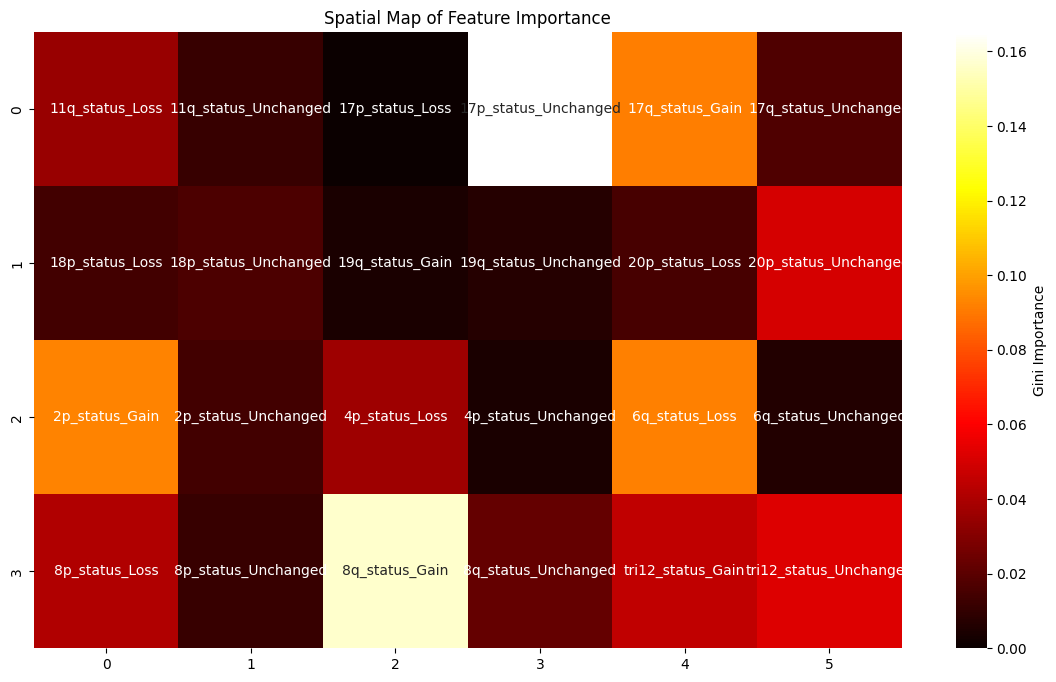

In [16]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Get your 24 feature names and importances
feature_names = X.columns.values
importances = tree.feature_importances_


# 2. Reshape both into 4x6 grids
# Ensure these are exactly 24 elements!
name_matrix = feature_names.reshape(4, 6)
importance_matrix = importances.reshape(4, 6)

# 3. Create the plot
plt.figure(figsize=(14, 8))
sns.heatmap(importance_matrix, 
            annot=name_matrix, # This puts the names in the boxes
            fmt="",            # Tells seaborn the names are strings
            cmap='hot', 
            cbar_kws={'label': 'Gini Importance'})

plt.title("Spatial Map of Feature Importance")
plt.show()